## Retail Sales Performance Analysis

## 1. Problem Statement
The goal Of this project is to analyze retail sales data to identify trends, profitability, and key business insights across categories, regions, and customer segments.

## 2. Data Loading and Understanding 

In [63]:
import pandas as pd
df = pd.read_csv(r"C:\Users\HP\Desktop\Superstore.csv")

In [64]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [35]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [36]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 3. Data Cleaning 

In [37]:
# Standardizing column names
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

## 4. Exploratory Data Analysis (EDA)

In [38]:
df['category'].value_counts()

category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [39]:
df['sub-category'].value_counts()

sub-category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [40]:
df['region'].value_counts()

region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [41]:
df['segment'].value_counts()

segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [42]:
# Sales by Category
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

In [43]:
# Profit by Category
df.groupby('category')['profit'].sum().sort_values(ascending=False)


category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

Insight: Technology category generates the highest profit while furniture has significantly lower profitability.

In [44]:
# Profit by Sub-category
df.groupby('sub-category')['profit'].sum().sort_values()

sub-category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: profit, dtype: float64

Insight: Tables and Bookcases are generating significant losses likely due to high discount levels.

In [45]:
# Average Discount by Sub-category
df.groupby('sub-category')['discount'].mean().sort_values(ascending=False)

sub-category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: discount, dtype: float64

Insight: Binders, Machines, and Tables have the highest average discount, which may be impacting profitability.

In [46]:
# geographic performance.
df.groupby('region')['profit'].sum().sort_values(ascending=False)

region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64

Insight: West region is the most profitable while central shows weaker performance. 

In [47]:
df.groupby('region')['sales'].sum().sort_values(ascending=False)

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

Insight: West region has the highest sales, followed by East.

In [49]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')

In [50]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

In [51]:
df.groupby('year')['sales'].sum()

year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: sales, dtype: float64

Insight: Sales show growth over time, indicating business expansion.

In [53]:
df.groupby('month')['sales'].sum()

month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: sales, dtype: float64

In [54]:
# segment analysis
df.groupby('segment')[['sales','profit']].sum()

,sales,profit
segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


Insight: Consumer segment generates the highest sales and profit Compared to corporate and Home Office.

## 5. Data visualisation

In [57]:
import matplotlib.pyplot as plt

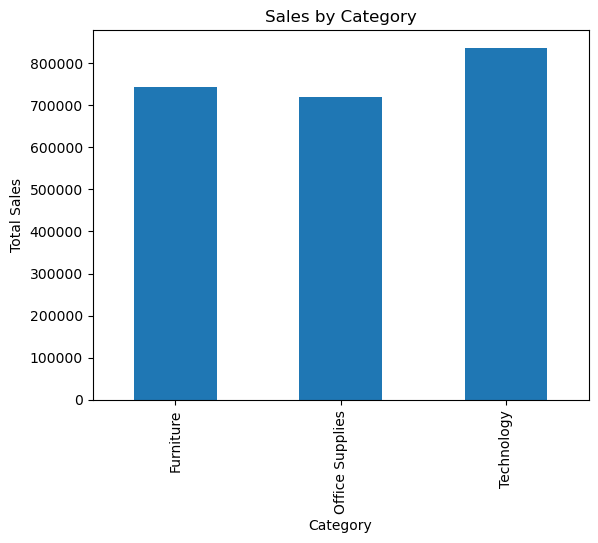

In [58]:
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

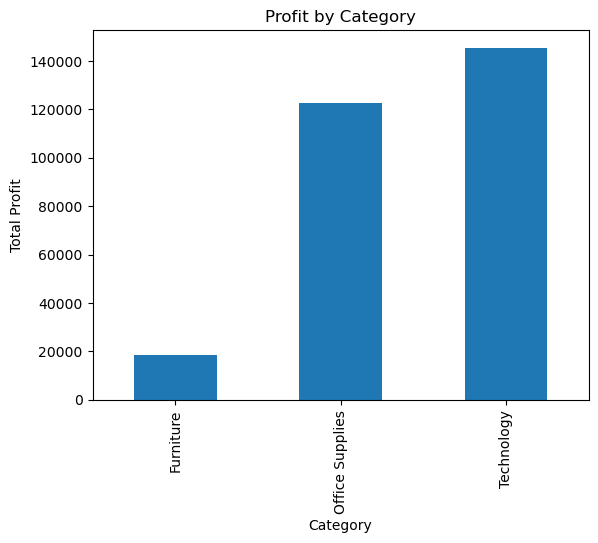

In [59]:
df.groupby('category')['profit'].sum().plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.show()

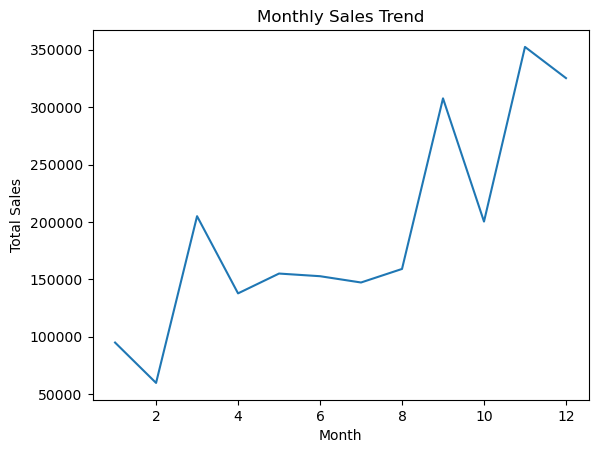

In [60]:
df.groupby('month')['sales'].sum().plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

## 6. Business Recommendations
1. Reduce discounts on loss-making sub-categories such as Tables and Bookcase.
2. Focus on expanding Technology, category due to high profitability.
3. Optimize pricing strategies to improve margins.
4. Increase focus on high performing regions like West and East. 

## 7. Final Insights
1. Technology is the most profitable category
2. Furniture has high sales but low profit
3. Tables and Bookcases generate losses
4. High discounts reduce profitability
5. West region performs best
6. Sales show growth trend over time 
7. Consumer segment contributes the most revenue
8. Sales peak in November and December, indicating strong seasonal demand.